检测系统配置

In [1]:
import os
print('CPU可用核心数:',os.cpu_count())

CPU可用核心数: 52


In [2]:
#获取GPU可用性
import tensorflow as tf
print('GPU可用性:',tf.test.is_gpu_available())
print("可用GPU数: ", len(tf.config.experimental.list_physical_devices('GPU')))

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU可用性: True
可用GPU数:  2


2025-08-04 16:00:22.572753: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-04 16:00:25.097747: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /device:GPU:0 with 30980 MB memory:  -> device: 0, name: Tesla V100-PCIE-32GB, pci bus id: 0000:65:03.0, compute capability: 7.0
2025-08-04 16:00:25.101597: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /device:GPU:1 with 30980 MB memory:  -> device: 1, name: Tesla V100-PCIE-32GB, pci bus id: 0000:65:04.0, compute capability: 7.0


查看单个数据项

In [3]:
#读取并可视化PNG格式数据
import cv2
import matplotlib.pyplot as plt
def ShowPNGImage(path):
    PNGImage=cv2.imread('/root/'+str(path))
    print('数据尺寸为:',PNGImage.shape)
    PNGFigure=plt.figure(dpi=300)
    plt.imshow(PNGImage)
    plt.show()

数据尺寸为: (512, 512, 3)


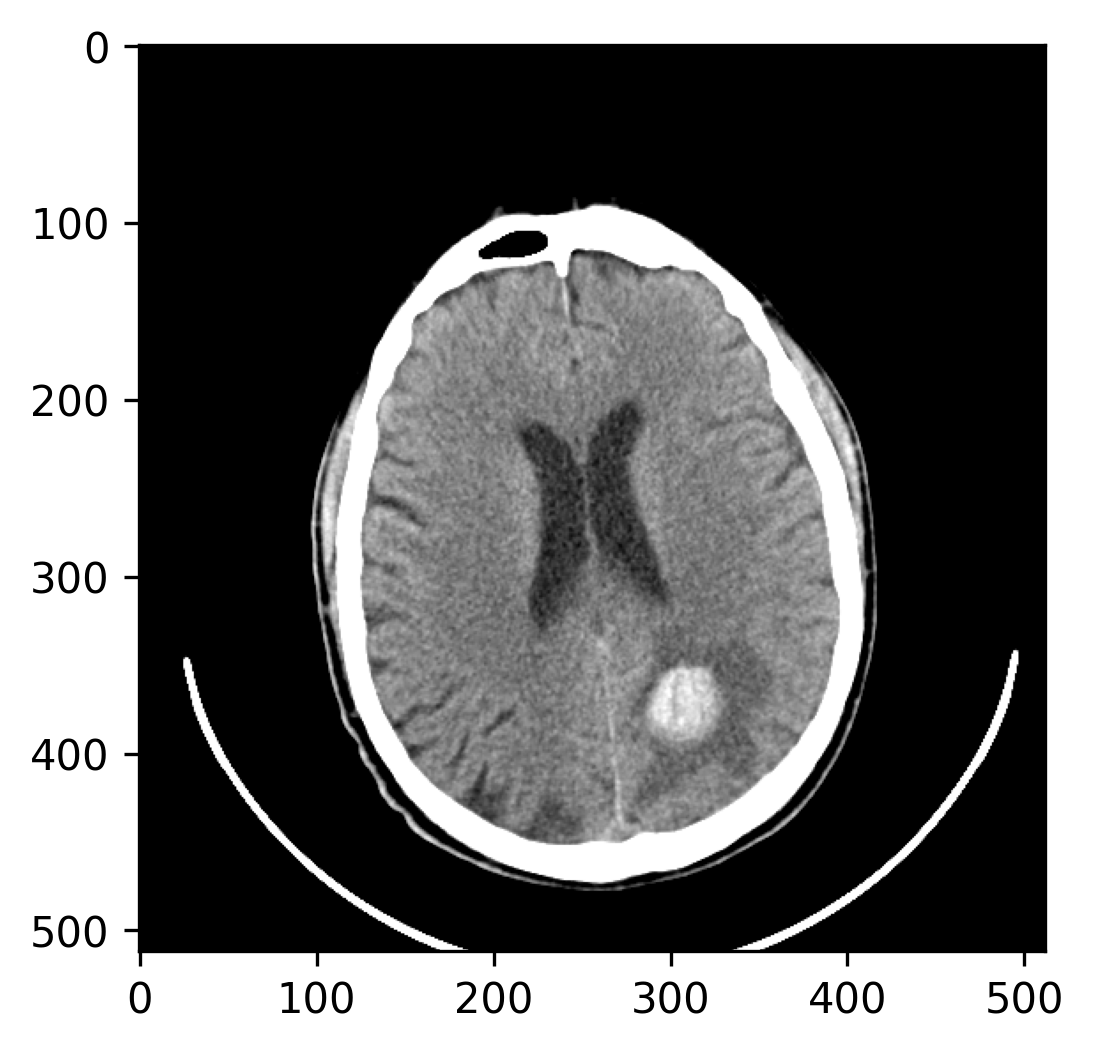

In [4]:
#读取出血组PNG数据
ShowPNGImage(path='StrokeDataset/Bleeding/PNG/10036.png')

数据尺寸为: (512, 512, 3)


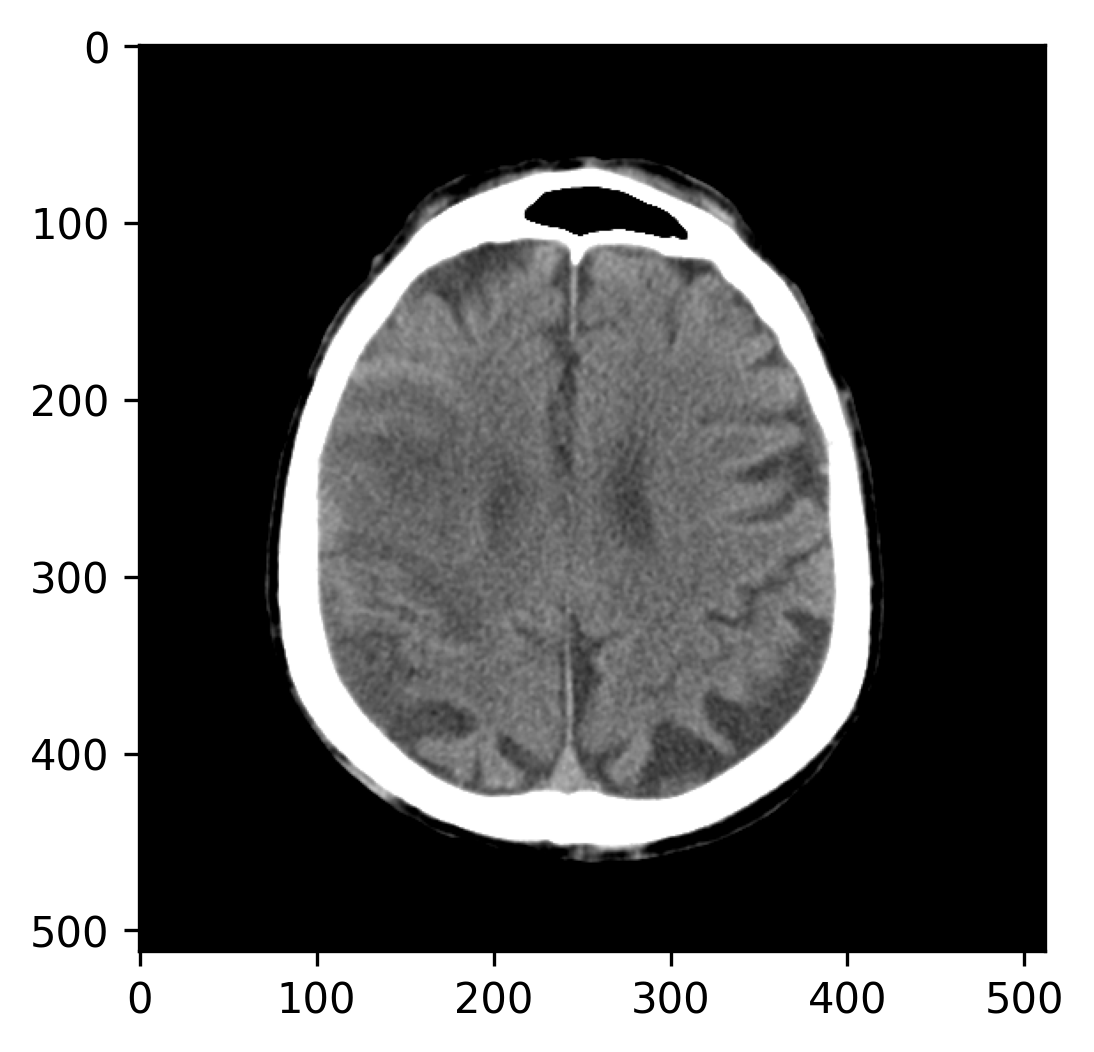

In [5]:
#读取缺血组PNG数据
ShowPNGImage(path='StrokeDataset/Ischemia/PNG/10003.png')

数据尺寸为: (512, 512, 3)


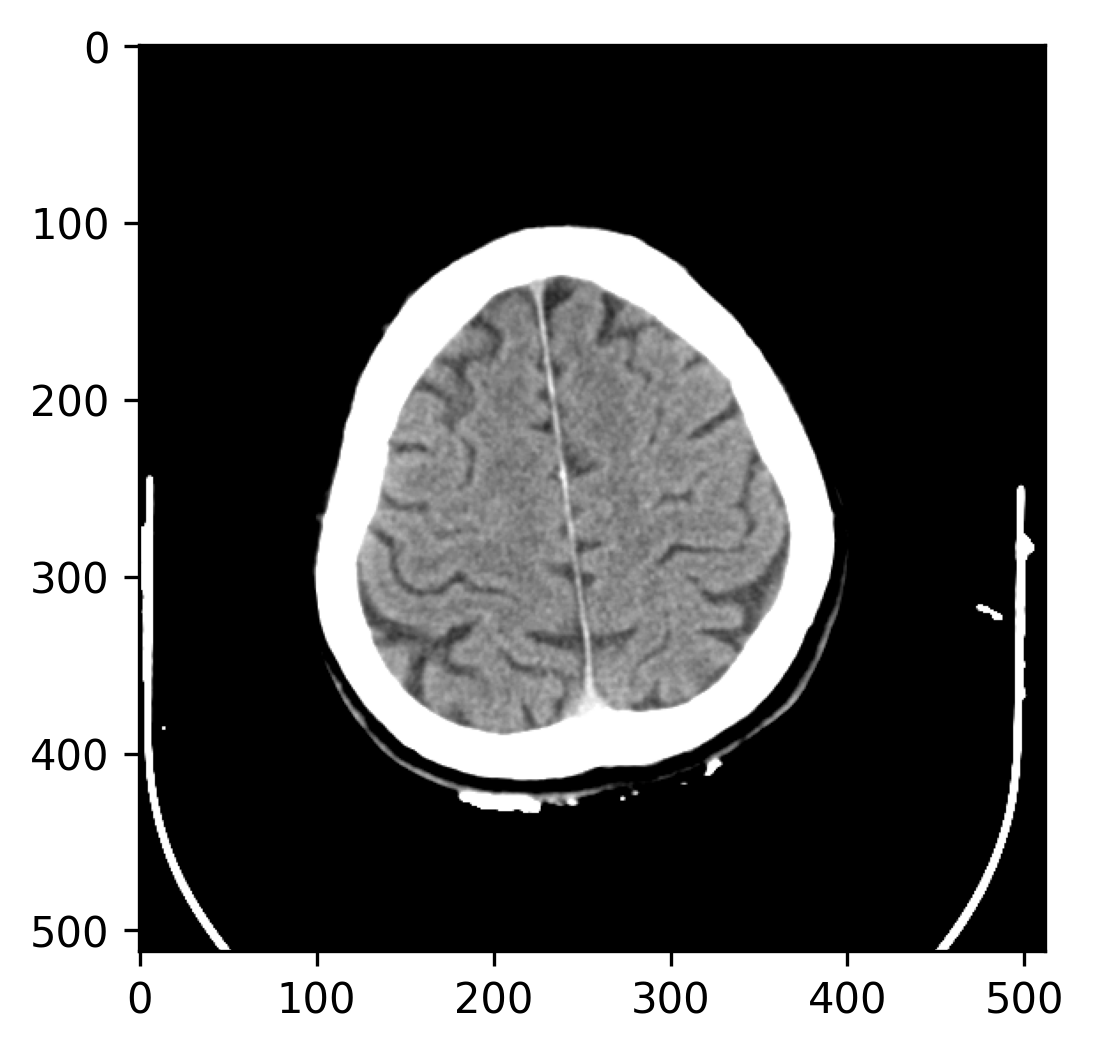

In [6]:
#读取正常组PNG数据
ShowPNGImage(path='StrokeDataset/Normal/PNG/10000.png')

In [7]:
#显示卒中组原始图和分割图
def ShowPNG_Overlayer(pngpath,overlayerpath):
    PNGImage=cv2.imread('/root/'+str(pngpath))
    OverImage=cv2.imread('/root/'+str(overlayerpath))
    MASK=OverImage-PNGImage
    print('PNG数据形状为:{0},Over layer数据形状为:{1}'.format(PNGImage.shape,OverImage.shape))
    plt.figure(figsize=(15,5),dpi=300)
    plt.subplot(1,3,1)
    plt.title('Raw Image')
    plt.imshow(PNGImage)
    plt.subplot(1,3,2)
    plt.title('Over layer Image')
    plt.imshow(OverImage)
    plt.subplot(1,3,3)
    plt.title('MASK layer Image')
    plt.imshow(MASK)
    plt.show()

PNG数据形状为:(512, 512, 3),Over layer数据形状为:(512, 512, 3)


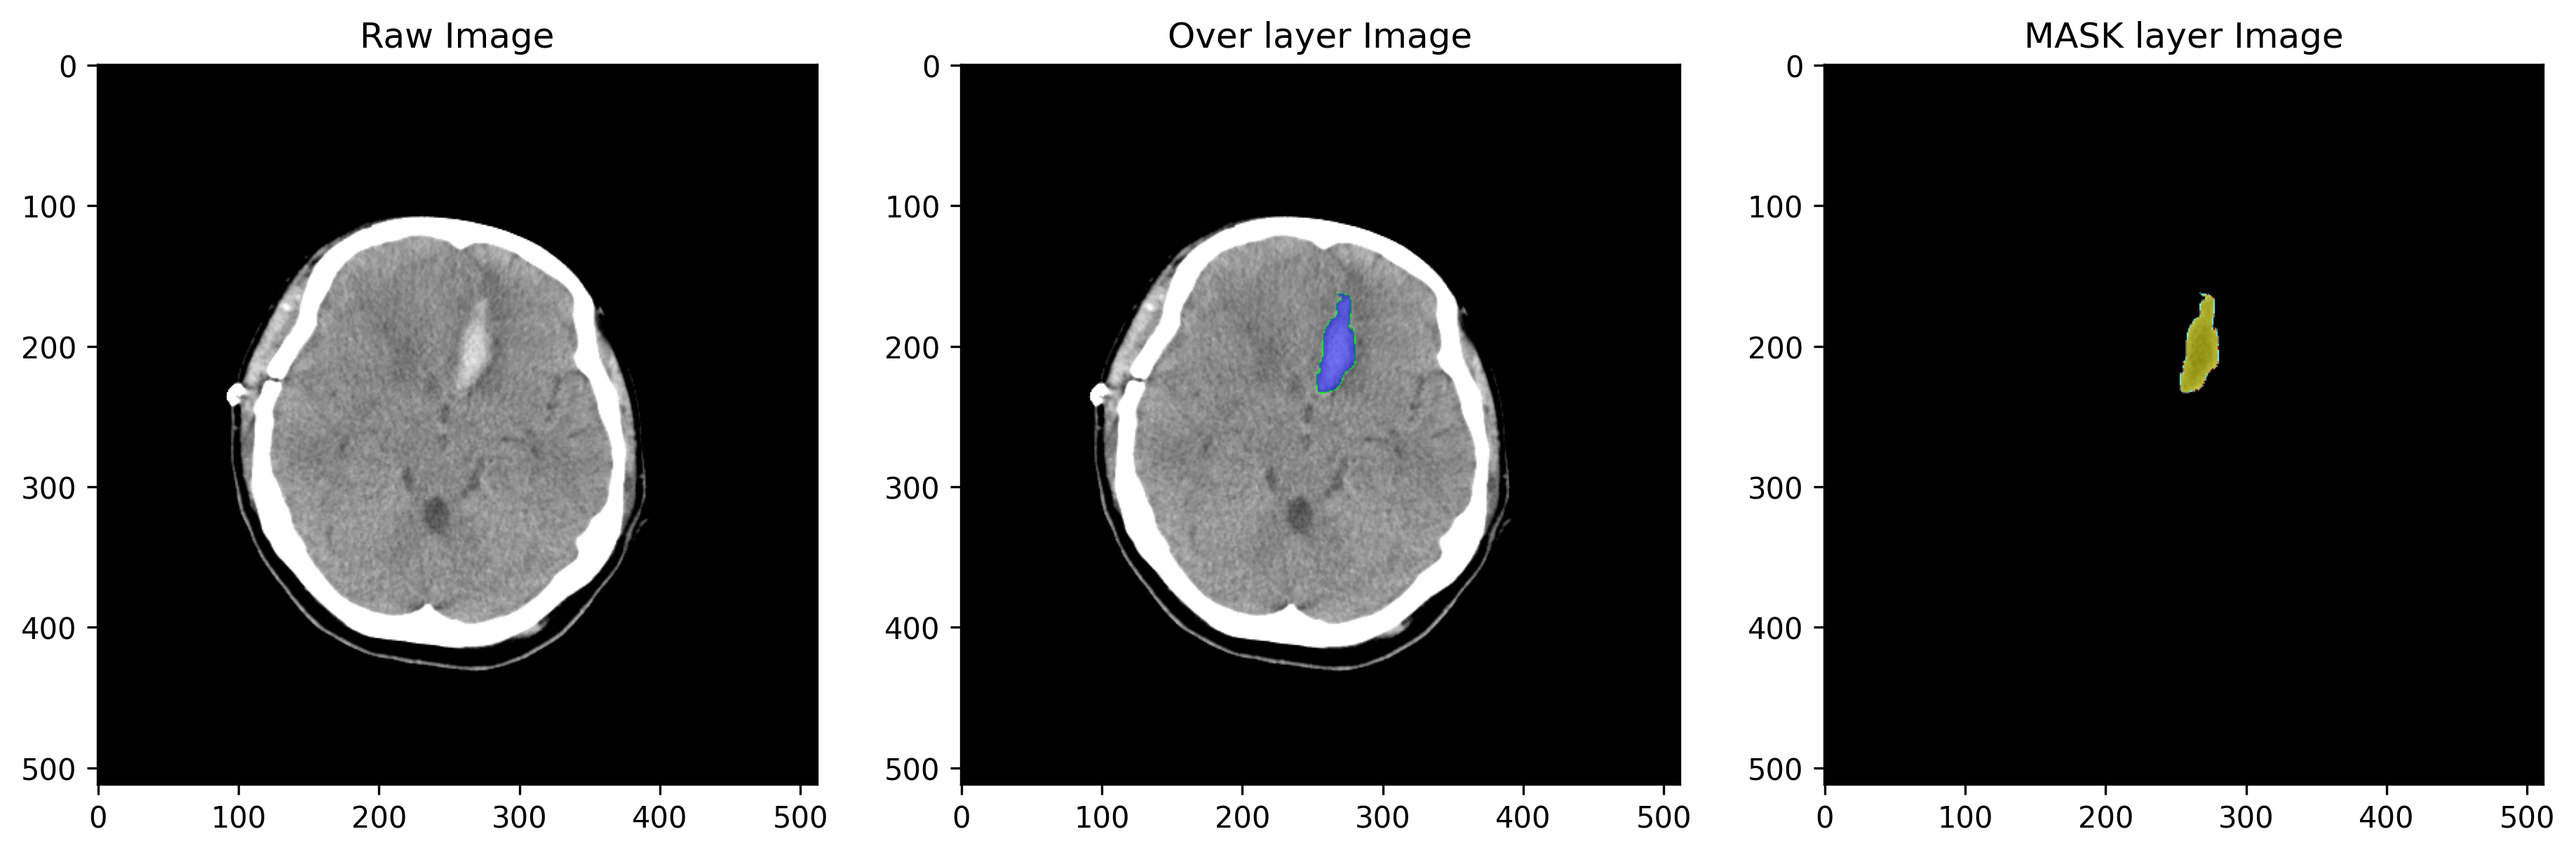

In [8]:
#读取出血组OVERLAY数据
ShowPNG_Overlayer(pngpath='StrokeDataset/Bleeding/PNG/10002.png',overlayerpath='StrokeDataset/Bleeding/OVERLAY/10002.png')

PNG数据形状为:(512, 512, 3),Over layer数据形状为:(512, 512, 3)


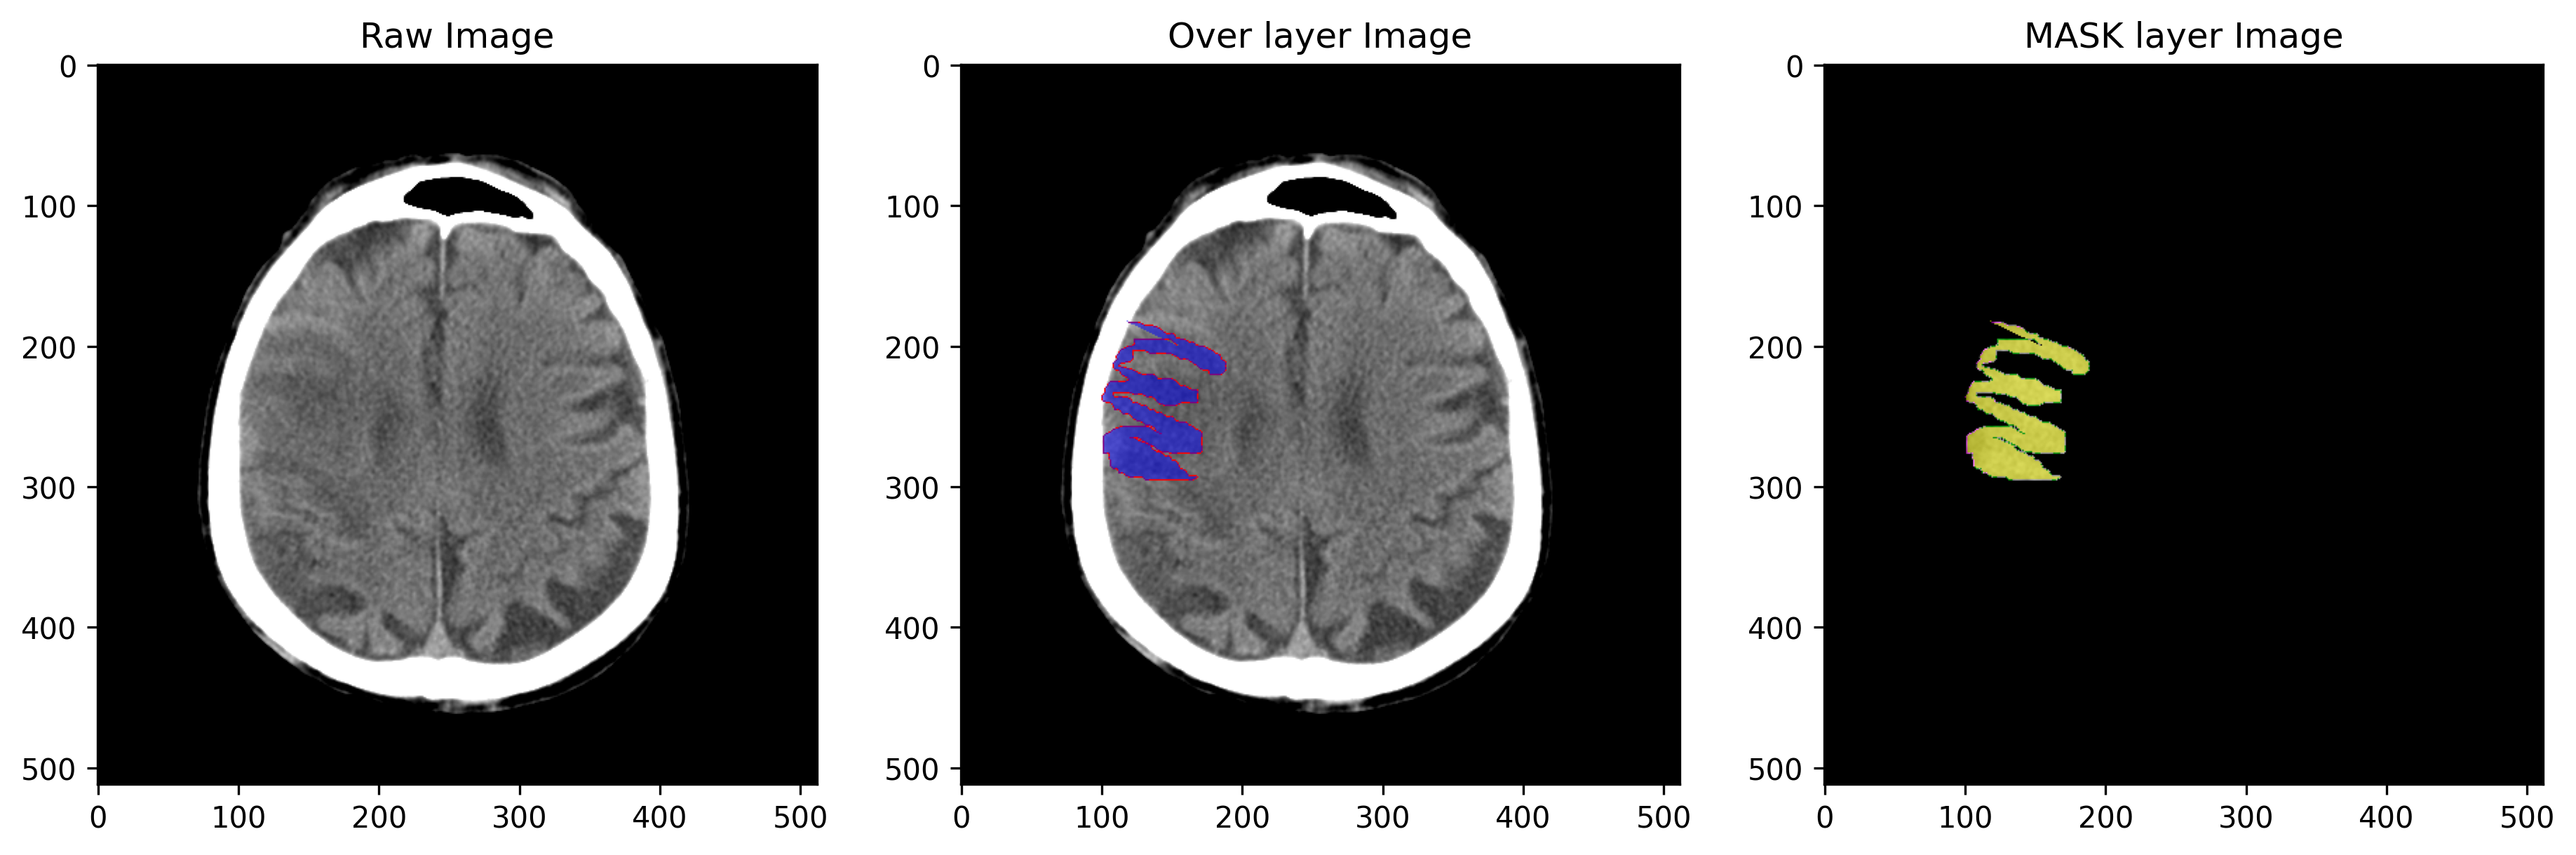

In [9]:
#读取缺血组OVERLAY数据
ShowPNG_Overlayer(pngpath='StrokeDataset/Ischemia/PNG/10003.png',overlayerpath='StrokeDataset/Ischemia/OVERLAY/10003.png')

In [10]:
#读取DICOM文件
from pydicom import dcmread
import numpy as np
def ShowDICOM(path):
    dicomdata=dcmread('/root/'+str(path))
    print(f"图像尺寸: {dicomdata.Rows} x {dicomdata.Columns}")
    window_center=dicomdata.WindowCenter[0]    #窗位
    window_width=dicomdata.WindowWidth[0]    #窗宽
    print(f'窗宽:{window_width},窗位:{window_center}')
    pixel_array=dicomdata.pixel_array
    # 应用窗宽窗位调整
    if window_center is not None and window_width is not None:
        min_val=window_center - window_width / 2
        max_val=window_center + window_width / 2
        #对像素值进行截断
        pixel_array = np.clip(pixel_array, min_val, max_val)
        #归一化到0-255
        pixel_array = ((pixel_array - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    # 创建图像
    plt.figure(figsize=(10, 10))
    plt.imshow(pixel_array, cmap='gray')
    plt.title(f"DICOM Image - {dicomdata.PatientID if hasattr(dicomdata, 'PatientID') else 'Nan'}")
    plt.show()

图像尺寸: 512 x 512
窗宽:80,窗位:35


/root/miniconda3/lib/python3.8/site-packages/pydicom/pixel_data_handlers/pillow_handler.py:238: UserWarning: The (0028,0101) 'Bits Stored' value (12-bit) doesn't match the JPEG 2000 data (16-bit). It's recommended that you change the 'Bits Stored' value
  warnings.warn(


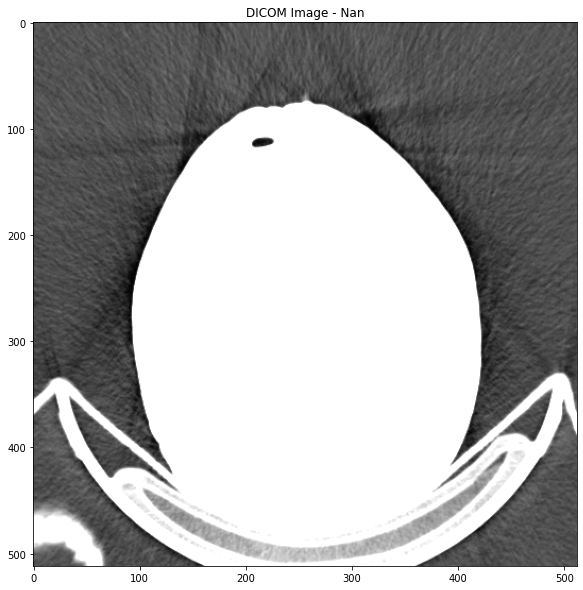

In [11]:
ShowDICOM(path='StrokeDataset/Bleeding/DICOM/10036.dcm')

读取文件路径和转化标签

In [12]:
#获取图片文件路径
import tqdm,os
ImageDirList=[]
FileAllPath=['/root/StrokeDataset/Bleeding/PNG','/root/StrokeDataset/Ischemia/PNG','/root/StrokeDataset/Normal/PNG']    #总文件路径
for fileallpath in tqdm.tqdm(FileAllPath):
    FilePath=os.listdir(fileallpath)    #读取总文件夹下文件
    for filepath in FilePath:
        Filepath=fileallpath+'/'+str(filepath)
        ImageDirList.append(Filepath)

100%|██████████| 3/3 [00:00<00:00, 456.48it/s]


In [13]:
#进行图像标签转化
import pandas
from pandas import DataFrame
def LabelEncoder(filepath):
    Path=set(filepath)
    paths=list(Path)    #打乱数据集
    ImageFile=DataFrame()
    imagepathlist,imagelabelpath=[],[]
    #'Normal':正常,'Ischemia':缺血,'Bleeding':出血
    LabelEncoder={'Normal':0,'Ischemia':1,'Bleeding':2}    #数据编码规则
    for imagepath in paths:
        label=imagepath.split('/')[3]    #获取标签
        labelencoder=LabelEncoder[label]    #获取标签数据
        imagepathlist.append(imagepath)
        imagelabelpath.append(labelencoder)
    ImageFile['Iamge Path']=imagepathlist
    ImageFile['Iamge Label']=imagelabelpath
    return ImageFile

In [14]:
#获取文件路径
ImageFile=LabelEncoder(filepath=ImageDirList)
ImageFile.to_csv('StrokeDataset/ImageFiles.csv',encoding='utf-8')

数据类别统计: Counter({0: 4427, 1: 1130, 2: 1093})


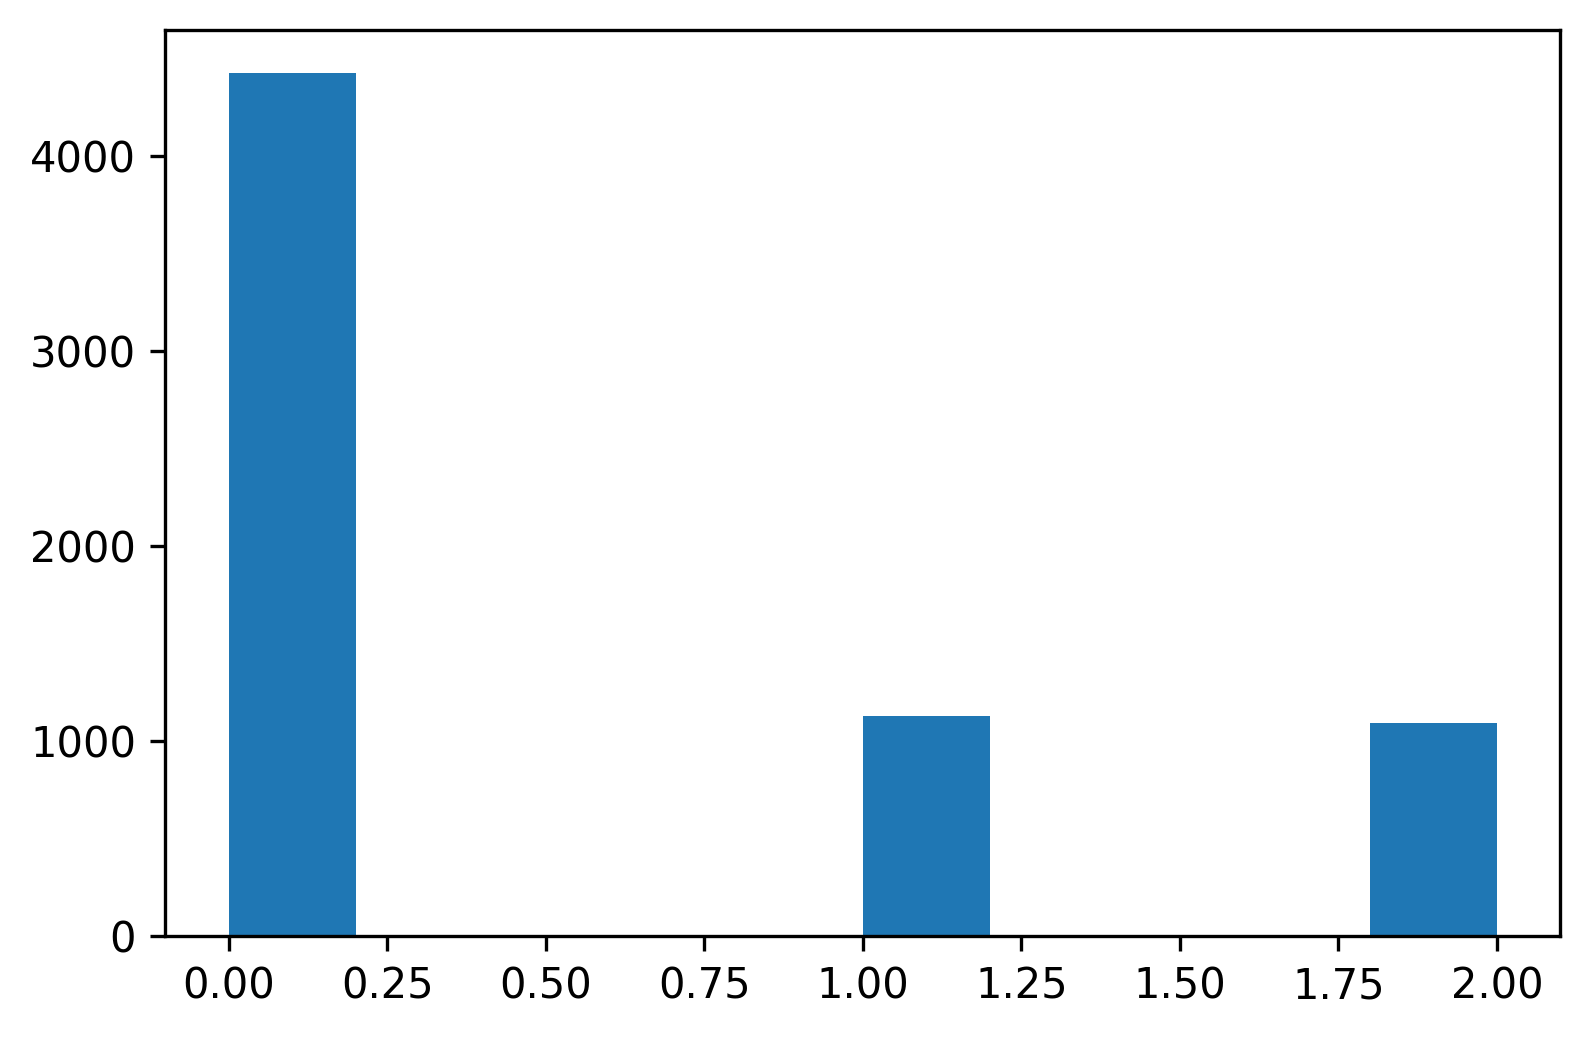

In [15]:
#统计数据分布
import matplotlib.pyplot as plt
from collections import Counter
print('数据类别统计:',Counter(ImageFile['Iamge Label']))
hist=plt.figure(dpi=300)
plt.hist(ImageFile['Iamge Label'])
plt.show()

查看图像数据

In [16]:
#应用马尔可夫随机场(MRF)(基于GMM + 空间约束)进行图像增强
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import numpy as np
def MRF_Tager(image_path, n_components, spatial_weight=0.5):
    # 加载图像
    img =cv2.imread(image_path)
    img_array = np.array(img)
    height, width, channels = img_array.shape
    # 构建特征矩阵：像素值 + 空间坐标
    pixels = img_array.reshape(-1, channels)  # 像素值特征
    coords = np.mgrid[0:height, 0:width].reshape(2, -1).T  # 空间坐标特征
    # 组合特征并标准化
    features = np.hstack([pixels, spatial_weight * coords])
    features = StandardScaler().fit_transform(features)
    gmm = GaussianMixture(n_components=n_components, random_state=2025)    # 使用GMM进行聚类（分割）
    labels = gmm.fit_predict(features)
    segmentation = labels.reshape(height, width)        # 重塑为图像形状
    return img_array, segmentation

In [17]:
#显示MRF图像
def MRFdisplay(original_np,enhanced_np,n_components):
    plt.imshow(original_np)
    plt.imshow(enhanced_np, cmap=plt.cm.get_cmap('viridis'),alpha=1.0)
    plt.colorbar(ticks=range(n_components))

In [18]:
#查看数据,包含马尔可夫随机场处理
import cv2
import matplotlib.pyplot as plt
def ShowImage(NormaPath,IschemiaPath,BleedingPath,n_components): 
    ControlImage=cv2.imread(NormaPath)    #正常患者图像
    Control,ControlMRF=MRF_Tager(image_path=NormaPath, n_components=n_components, spatial_weight=0.5)    #MRF
    Ischemiamage=cv2.imread(IschemiaPath)    #读取缺血患者数据
    Ischemia,IschemiaMRF=MRF_Tager(image_path=IschemiaPath, n_components=n_components, spatial_weight=0.5)    #MRF
    BleedingImage=cv2.imread(BleedingPath)    #读取出血患者数据
    Bleeding,BleedingMRF=MRF_Tager(image_path=BleedingPath, n_components=n_components, spatial_weight=0.5)    #MRF
    plt.figure(figsize=(20, 15))
    plt.subplot(2, 3, 1)    #正常患者图像
    plt.title('Normal Image')
    plt.imshow(ControlImage)  
    plt.subplot(2, 3, 4)
    plt.title('MRF Normal Image')
    MRFdisplay(original_np=Control,enhanced_np=ControlMRF,n_components=n_components)
    plt.subplot(2, 3, 2)
    plt.title('Ischem Iamage')
    plt.imshow(Ischemiamage)
    plt.subplot(2, 3, 5)
    plt.title('MRF Ischemia Image')
    MRFdisplay(original_np=Ischemia,enhanced_np=IschemiaMRF,n_components=n_components)
    plt.subplot(2, 3, 3)    #PCOS患者图像
    plt.title('Bleeding Image')
    plt.imshow(BleedingImage)  
    plt.subplot(2, 3, 6)
    plt.title('MRF Bleeding Image')
    MRFdisplay(original_np=Bleeding,enhanced_np=BleedingMRF,n_components=n_components)
    plt.show()

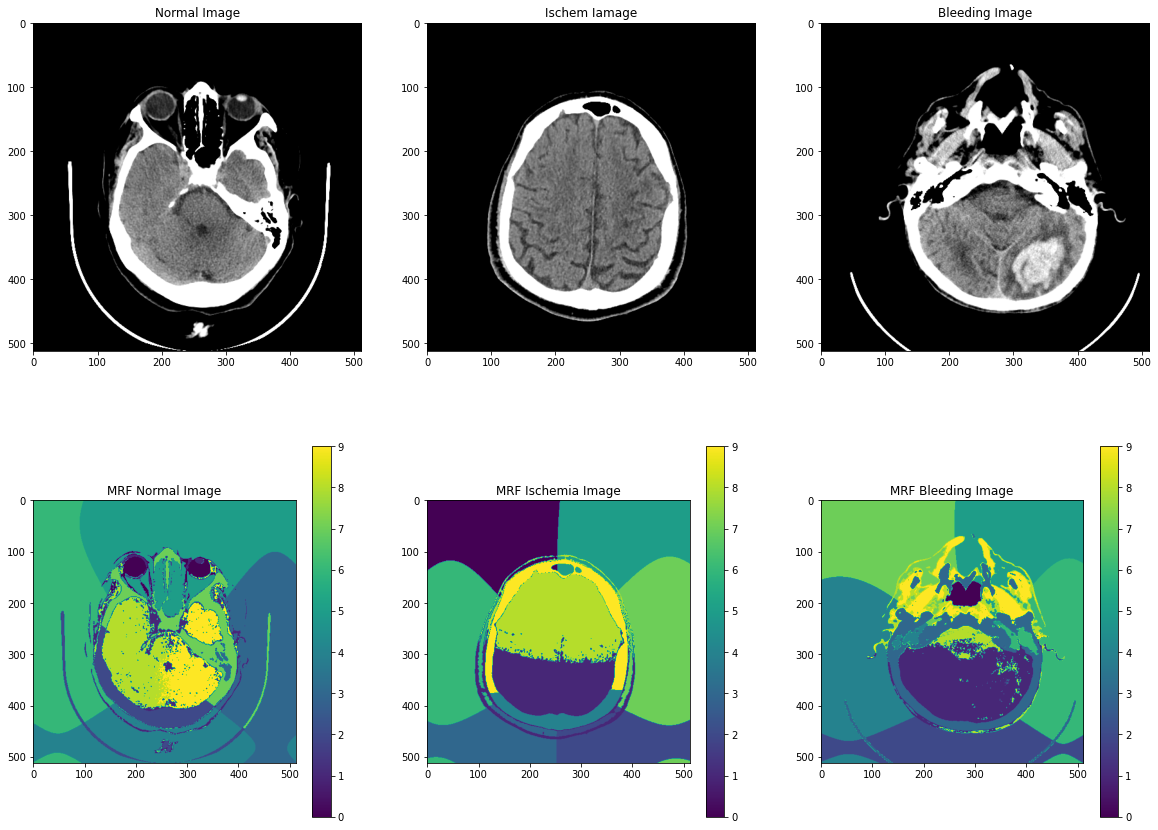

In [19]:
ShowImage(NormaPath='StrokeDataset/Normal/PNG/16967.png',
          IschemiaPath='StrokeDataset/Ischemia/PNG/13584.png',
          BleedingPath='StrokeDataset/Bleeding/PNG/12361.png',n_components=10)

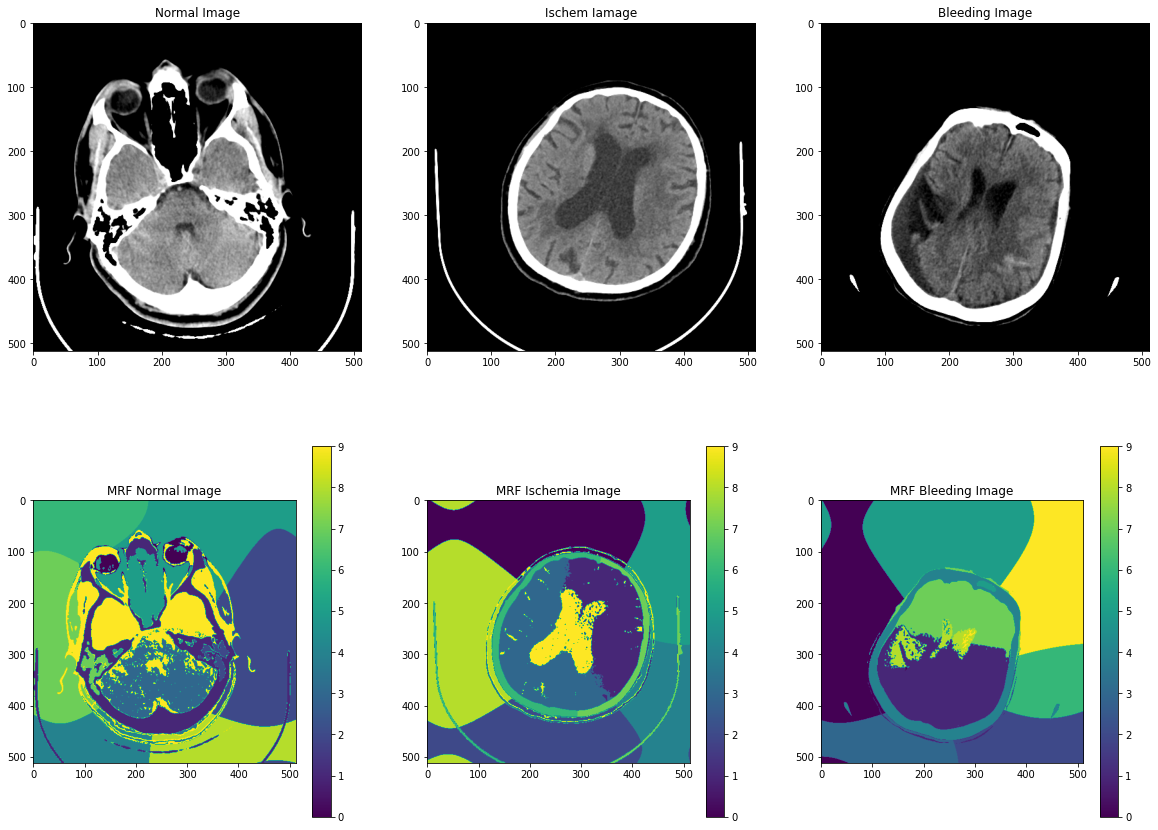

In [20]:
ShowImage(NormaPath='StrokeDataset/Normal/PNG/10400.png',
          IschemiaPath='StrokeDataset/Ischemia/PNG/15336.png',
          BleedingPath='StrokeDataset/Bleeding/PNG/14699.png',n_components=10)

In [1]:
#读取文件地址
import pandas as pd
ImageFile=pd.read_csv('/root/StrokeDataset/ImageFiles.csv')

构建数据输入流

In [2]:
#分割数据集+分层抽样
from sklearn.model_selection import train_test_split
TrainPath,SplitPath,TrainLabel,SplitLabel=train_test_split(ImageFile.loc[:,'Iamge Path'],ImageFile.loc[:,'Iamge Label'],train_size=0.7,
                                                           stratify=ImageFile.loc[:,'Iamge Label'],random_state=2025)
ValidPath,TestPath,ValidLabel,TestLabel=train_test_split(SplitPath,SplitLabel,train_size=0.5,stratify=SplitLabel,random_state=2025)
print('训练集地址:{0},验证集地址:{1},测试集地址:{2}'.format(len(TrainPath),len(ValidPath),len(TestPath)))
print('训练集标签:{0},验证集标签:{1},测试集标签:{2}'.format(len(TrainLabel),len(ValidLabel),len(TestLabel)))

训练集地址:4655,验证集地址:997,测试集地址:998
训练集标签:4655,验证集标签:997,测试集标签:998


In [3]:
#检测数据分布
import matplotlib.pyplot as plt
from collections import Counter
def EveluateLabel(labellist):
    print('样本标签统计:',Counter(labellist))
    hist=plt.figure(dpi=72)
    plt.hist(labellist)
    plt.show()

样本标签统计: Counter({0: 3099, 1: 791, 2: 765})


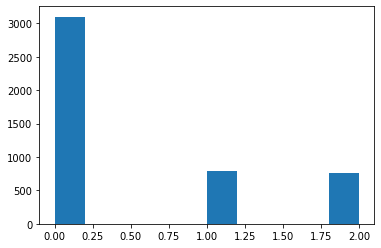

In [4]:
#训练集
EveluateLabel(labellist=TrainLabel)

样本标签统计: Counter({0: 664, 1: 169, 2: 164})


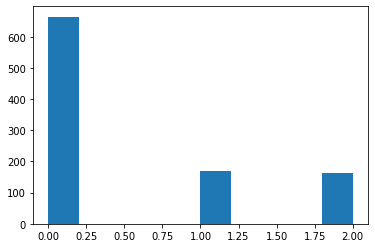

In [5]:
#验证集
EveluateLabel(labellist=ValidLabel)

样本标签统计: Counter({0: 664, 1: 170, 2: 164})


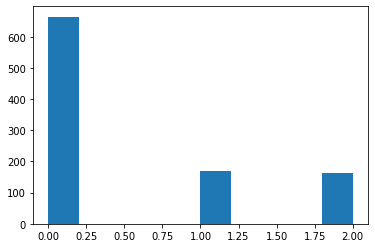

In [6]:
#测试集
EveluateLabel(labellist=TestLabel)

构建数据输入流

In [7]:
#编写数据读取函数
import tensorflow as tf
def ReadImageData(path,ImageLabel):
        image_io=tf.io.read_file(path)    #读取文件
        image_data=tf.image.decode_png(image_io,channels=3)    #解码图像数据
        image_datare=tf.image.resize(image_data,(512,512))
        image_normal=tf.cast(image_datare, tf.float32)/255.0
        return (image_normal,ImageLabel)

In [8]:
#使用文件路径方法批量读取数据
#训练集
FilePathDataset_Train=tf.data.Dataset.from_tensor_slices((TrainPath,TrainLabel)).repeat(2)    #文件路径数据集
ImageDataset_Train=FilePathDataset_Train.shuffle(buffer_size=1000,seed=2025).map(ReadImageData,num_parallel_calls=tf.data.experimental.AUTOTUNE)    #获取文件路径
ImageDataset_Train=ImageDataset_Train.batch(batch_size=100).prefetch(tf.data.experimental.AUTOTUNE)
#验证集
FilePathDataset_Valid=tf.data.Dataset.from_tensor_slices((ValidPath,ValidLabel)).repeat(2)    #文件路径数据集
ImageDataset_Valid=FilePathDataset_Valid.shuffle(buffer_size=1000,seed=2025).map(ReadImageData,num_parallel_calls=tf.data.experimental.AUTOTUNE)    #获取文件路径
ImageDataset_Valid=ImageDataset_Valid.batch(batch_size=100).prefetch(tf.data.experimental.AUTOTUNE)
#测试集
FilePathDataset_Test=tf.data.Dataset.from_tensor_slices((TestPath,TestLabel)).repeat(2)    #文件路径数据集
ImageDataset_Test=FilePathDataset_Test.shuffle(buffer_size=1000,seed=2025).map(ReadImageData,num_parallel_calls=tf.data.experimental.AUTOTUNE)    #获取文件路径
ImageDataset_Test=ImageDataset_Test.batch(batch_size=100).prefetch(tf.data.experimental.AUTOTUNE)

2025-08-04 16:06:55.438598: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-04 16:06:57.603764: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 30980 MB memory:  -> device: 0, name: Tesla V100-PCIE-32GB, pci bus id: 0000:65:03.0, compute capability: 7.0
2025-08-04 16:06:57.605140: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 30980 MB memory:  -> device: 1, name: Tesla V100-PCIE-32GB, pci bus id: 0000:65:04.0, compute capability: 7.0


模型构建

In [9]:
#构建卷积神经网络专家模型
from tensorflow import keras
#Input shape[512,512,3];Output shape[14,14,64]
def ConvD2DModel(activation):
    EncoderImage=keras.models.Sequential([])
    EncoderImage.add(keras.layers.Input(shape=[512,512,3]))
    #Conv2D Blocks1 300--148
    EncoderImage.add(keras.layers.Conv2D(filters=9,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=9,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=None,padding='valid',data_format='channels_last'))
    #Conv2D Blocks2 148--72
    EncoderImage.add(keras.layers.Conv2D(filters=18,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=18,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=None,padding='valid',data_format='channels_last'))
    #Conv2D Blocks3 72--34
    EncoderImage.add(keras.layers.Conv2D(filters=36,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=36,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=None,padding='valid',data_format='channels_last'))
    #Conv2D Blocks4 34--15
    EncoderImage.add(keras.layers.Conv2D(filters=64,kernel_size=(3,3),strides=(1,1),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.Conv2D(filters=64,kernel_size=(3,3),strides=(2,2),activation=activation,padding='valid',dilation_rate=(1,1),
                                      data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros'))
    EncoderImage.add(keras.layers.MaxPool2D(pool_size=(2,2),strides=(2,2),padding='valid',data_format='channels_last',name='Output_Encoder'))
    return EncoderImage

In [ ]:
#定义卷积路由器
class ConvidRounter(keras.layers.Layer):
    def __init__(self,ImageShape,**kwargs):
        super().__init__(**kwargs)
        #卷积Router参数
        self.ImageShape=ImageShape    #输入图像大小
        #定义卷积Router模块
        self.InputLayer = keras.layers.InputLayer(input_shape=self.ImageShape)
        self.Conv2DInput=keras.layers.Conv2D(filters=20,kernel_size=(3,3),strides=(2,2),activation='relu',padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',
                                             bias_initializer='zeros',input_shape=self.ImageShape)
        self.Conv2D2=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.Conv2D3=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.MaxPooling=keras.layers.MaxPool2D(pool_size=(2, 2), strides=None, padding='valid', data_format='channels_last')
        self.Conv2D4=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.Conv2D5=keras.layers.Conv2D(filters=20, kernel_size=(3, 3), strides=(2, 2), activation='relu', padding='valid',dilation_rate=(1,1),
                                  data_format='channels_last',use_bias=True,kernel_initializer='glorot_uniform',bias_initializer='zeros')
        self.Flatten=keras.layers.Flatten()
        self.Dense=keras.layers.Dense(units=128, activation='relu',kernel_initializer='lecun_normal',kernel_regularizer=None,
                   kernel_constraint=None)
        self.Problity=keras.layers.Dense(units=4,activation='softmax',kernel_initializer='lecun_normal',kernel_regularizer=None,
                   kernel_constraint=None)
    def call(self,inputs):
        Input=self.InputLayer(inputs)
        Conv2DOut1=self.Conv2DInput(Input)    #卷积模块
        Conv2DOut2=self.Conv2D2(Conv2DOut1)
        Conv2DOut3=self.Conv2D3(Conv2DOut2)
        MaxPool1=self.MaxPooling(Conv2DOut3)
        Conv2DOut4=self.Conv2D4(MaxPool1)
        Conv2DOut5=self.Conv2D5(Conv2DOut4)
        MaxPool2=self.MaxPooling(Conv2DOut5)    #Outshape[3,5,20]
        FlattenOut=self.Flatten(MaxPool2)
        DenseOut1=self.Dense(FlattenOut)
        ProbilityOut1=self.Problity(DenseOut1)    #Outshape[batch,4]
        return ProbilityOut1
    def compute_output_shape(self):
        return tf.TensorShape([-1,4])
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'ImageShape':self.ImageShape}

In [11]:
#基于MoE架构构建卷积MoE层
import tensorflow
from tensorflow import keras
class ConvidMoELayer(keras.layers.Layer):
    def __init__(self,Runter,Expoer1,Expoer2,Expoer3,Expoer4,**kwargs):
        super().__init__(**kwargs)
        self.Runter=Runter    #定义路由器模型
        #专家模型
        self.ConvidExpert1=Expoer1
        self.ConvidExpert2=Expoer2
        self.ConvidExpert3=Expoer3
        self.ConvidExpert4=Expoer4
    def call(self,inputs):
        #路由器模型输出概率
        RouterProblityOut=self.Runter(inputs)
        #计算专家模型输出 输入数据[512, 512,3]
        #Expert1
        Expert1Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #Expert2
        Expert2Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #Expert3
        Expert3Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #Expert4
        Expert4Out=self.ConvidExpert1(inputs)    #输出[14,14,64]
        #整合专家模型输出结果
        ExpertOut=[Expert1Out,Expert2Out,Expert3Out,Expert4Out]    #输出[batch_size, 14, 14，64]
        # 将路由器输出的概率值扩展为与专家输出相同的维度
        router_output_expanded=tf.expand_dims(RouterProblityOut, axis=1)  # [batch_size, 1, 4]
        router_output_expanded=tf.expand_dims(router_output_expanded, axis=1)  # [batch_size, 1, 1, 4]
        router_output_expanded=tf.tile(router_output_expanded, [1, 14, 14, 1])  # [batch_size, 14, 14, 4]
        #将专家输出与路由器概率相乘
        weighted_expert_outputs=[expert_output * router_output_expanded[:, :, :, i:i+1] for i, expert_output in enumerate(ExpertOut)]
        # 展开通道维度并拼接
        reshaped_outputs = [tf.reshape(output, [-1, 14, 896]) for output in weighted_expert_outputs]  # 形状为[batch_size, 14,896]
        MoEOut= tf.concat(reshaped_outputs, axis=1)  # 形状为[batch_size,56,896]
        return MoEOut
    def compute_output_shape(self):
        return tf.TensorShape([56,896])
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'Runter':self.Runter,'Expoer1':self.ConvidExpert1,'Expoer2':self.ConvidExpert2,'Expoer3':self.ConvidExpert3,
                'Expoer4':self.ConvidExpert4}

In [12]:
#定义SwiGLU激活单元
class SwiGLU(keras.layers.Layer):
    def __init__(self,input_dim,output_dim,**kwargs):
        #input [batchsize,input_dim]"
         #Output [batchsize,input_dim]
        super().__init__(**kwargs)
        self.input_dim=input_dim    #输入维度
        self.output_dim=output_dim   #输出维度
        self.linear1=keras.layers.Dense(input_dim=self.input_dim,units=self.output_dim)
        self.linear2=keras.layers.Dense(input_dim=self.input_dim,units=self.output_dim)
        self.linear3=keras.layers.Dense(input_dim=self.output_dim,units=self.input_dim)
    def call(self,inputs):
        x1=self.linear1(inputs)
        x2=self.linear2(inputs)
        swish_x1=tf.nn.swish(x1)
        SwishGLU=swish_x1*x2
        Output=self.linear3(SwishGLU)
        return Output
    def compute_output_shape(self):    #规范输出维度
        return tf.TensorShape([self.input_dim,self.input_dim])
    def get_config(self):
        Base_config=super().get_config()
        return {**Base_config,'input_dim':self.input_dim,'output_dim':self.output_dim}

In [13]:
#构建基于AugResEncoder层 
class AugResEncoder(keras.layers.Layer):
    def __init__(self,heads,key_dim,input_dim,Wdim,deep_dim,SwiGLU,**kwargs):
        super().__init__(**kwargs)
        self.heads=heads    #注意力头数
        self.key_d=key_dim    #Key维度
        self.input_dim=input_dim    #输入数据维度
        self.Wdim=Wdim    #矩阵维度
        self.deep_dim=deep_dim    #FFN维度升高
        self.SwiGLU=SwiGLU    #SwiGLU激活单元
        self.Multi_Head_Attention=keras.layers.MultiHeadAttention(num_heads=self.heads,key_dim=self.key_d)    #自注意力
        self.LayerNormaltion=keras.layers.LayerNormalization()    #层归一化
        self.LinearLayer1=keras.layers.Dense(input_dim=self.input_dim,units=self.Wdim,activation=None,use_bias=False)    #线性层    [input_dim---Wdim]
        self.Relu=keras.layers.ReLU()    #Relu激活函数
        self.LinearActivation=keras.layers.Dense(input_dim=self.Wdim,units=self.deep_dim,activation='selu',    #[Wdim---deep_dim]
                                                 kernel_initializer=None,use_bias=False)    #使用SELU激活函数的线性层
        self.LinearLayer2=keras.layers.Dense(input_dim=self.deep_dim,units=self.Wdim,activation=None,use_bias=False)    #线性层    [deep_dim---input_dim]
        self.AddLayer=keras.layers.Add()    #相加层
    def call(self,inputs):    #前向计算    [input_dim,Wdim]
        LayerNormal1=self.LayerNormaltion(inputs)
        MSA=self.Multi_Head_Attention(query=LayerNormal1,value=LayerNormal1,key=LayerNormal1)    #计算Multi-Head-attention
        ResLinear1=self.LinearLayer1(LayerNormal1)
        ResActivation=self.LinearActivation(ResLinear1) 
        ResLinear2=self.LinearLayer2(ResActivation)    #ResNet模块  
        ResAdd=self.AddLayer([ResLinear2,LayerNormal1])
        ResRelu=self.Relu(ResAdd)
        ResNet=self.AddLayer([MSA,ResRelu])    #残差连接
        #FFN模块
        LayerNormal2=self.LayerNormaltion(ResNet)
        #LinearOutput1=self.LinearLayer1(LayerNormal2)    #self.input_dim >> self.Wdim
        #LinearActiontion=self.LinearActivation(LinearOutput1)
        #LeakyRelu=self.Relu(LinearActiontion)
        #LinearOutput2=self.LinearLayer2(LeakyRelu)
        SwiGLU=self.SwiGLU(LayerNormal2)    #self.Wdim >> self.Wdim
        ResNet2=self.AddLayer([SwiGLU,LayerNormal2])
        return ResNet2
    def compute_output_shape(self):    #规范输出维度
        return tf.TensorShape([self.input_dim,self.Wdim])
    def get_config(self):
        Base_config=super().get_config()
        return {**Base_config,'heads':self.heads,'key_dim':self.key_d,'input_dim':self.input_dim,'Wdim':self.Wdim,'deep_dim':self.deep_dim,'SwiGLU':self.SwiGLU}

In [14]:
#构建卷积模块，选择不同激活函数
#ConvD2D_Relu=ConvD2DModel(activation='relu')
#ConvD2D_Tanh=ConvD2DModel(activation='tanh')
#ConvD2D_ELU=ConvD2DModel(activation='elu')
#ConvD2D_SELU=ConvD2DModel(activation='selu')

In [15]:
#ConvD2D_Relu.summary()

In [16]:
#ConvD2D_Tanh.summary()

In [17]:
#ConvD2D_ELU.summary()

In [18]:
#ConvD2D_SELU.summary()

In [19]:
#定义卷积路由器
#Conv2DRouter=ConvidRounter(ImageShape=(512,512,3))

In [14]:
#定义分类模块
def ClassModuleBluid():
    ClassModule=keras.models.Sequential([])
    ClassModule.add(keras.layers.Dense(units=300,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    ClassModule.add(keras.layers.Dropout(rate=0.5))
    ClassModule.add(keras.layers.Dense(units=150,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    ClassModule.add(keras.layers.Dropout(rate=0.5))
    ClassModule.add(keras.layers.Dense(units=100,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    ClassModule.add(keras.layers.Dropout(rate=0.5))
    ClassModule.add(keras.layers.Dense(units=50,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    return ClassModule

In [21]:
#SwiGLURe=SwiGLU(input_dim=896,output_dim=1792)

In [15]:
#构建ConvdMoEFormer模型
def CerebriScan():
    InputLayer=keras.layers.Input(shape=(512,512, 3),name='InputLayer')
    ConvdMoE=ConvidMoELayer(Runter=Conv2DRouter,Expoer1=ConvD2D_Relu,Expoer2=ConvD2D_Tanh,Expoer3=ConvD2D_ELU,Expoer4=ConvD2D_SELU)(InputLayer)    #MoE层[15,15,512]
    Aug_Res1=AugResEncoder(heads=28,key_dim=896,input_dim=56,Wdim=896,deep_dim=1792,SwiGLU=SwiGLURe)(ConvdMoE)
    Aug_Res2=AugResEncoder(heads=28,key_dim=896,input_dim=56,Wdim=896,deep_dim=1792,SwiGLU=SwiGLURe)(Aug_Res1)
    Aug_Res3=AugResEncoder(heads=28,key_dim=896,input_dim=56,Wdim=896,deep_dim=1792,SwiGLU=SwiGLURe)(Aug_Res2)
    Aug_Res4=AugResEncoder(heads=28,key_dim=896,input_dim=56,Wdim=896,deep_dim=1792,SwiGLU=SwiGLURe)(Aug_Res3)
    Add_Layer=keras.layers.Add()([ConvdMoE,Aug_Res4])
    Flatten=keras.layers.Flatten()(Add_Layer)
    Class_layer=ClassModuleBluid()(Flatten)
    Output_Layer=keras.layers.Dense(units=3,activation='softmax',name='OutputLayer')(Class_layer)
    CerebriScanModel=keras.models.Model(inputs=[InputLayer],outputs=[Output_Layer])
    return CerebriScanModel

In [23]:
#CerebriScan_V1.summary()

构建训练日志

In [16]:
#添加TensorBroad
import os,time
root_logdir=os.path.join('/root/tf-logs','CerebriScan_V3_logs')
def Get_run_logdir():
    run_id=time.strftime('run_%Y_%m_%d-%H_%M_%S')
    return os.path.join(root_logdir,run_id)
Run_LogsID=Get_run_logdir()
Tensorbroad_CallBacks=keras.callbacks.TensorBoard(Run_LogsID, histogram_freq=1)

In [17]:
#进行分布式训练
strategy=tf.distribute.MirroredStrategy()
with strategy.scope():
    #构建卷积模块，选择不同激活函数
    ConvD2D_Relu=ConvD2DModel(activation='relu')
    ConvD2D_Tanh=ConvD2DModel(activation='tanh')
    ConvD2D_ELU=ConvD2DModel(activation='elu')
    ConvD2D_SELU=ConvD2DModel(activation='selu')
    #定义卷积路由器
    Conv2DRouter=ConvidRounter(ImageShape=(512,512,3))
    SwiGLURe=SwiGLU(input_dim=896,output_dim=1792)
    CerebriScan_V3=CerebriScan()
    Loss=keras.losses.SparseCategoricalCrossentropy()
    Optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
    Metrics=['accuracy']
    LRSchudue=keras.callbacks.ReduceLROnPlateau(patience=100,factor=0.5)   #学习率调度
    CheckPoint=keras.callbacks.ModelCheckpoint('CerebriScan_V3',monitor='val_accuracy',mode='max',save_best_only=True,save_weights_only=False)
    EarlyStoping=keras.callbacks.EarlyStopping(patience=100,monitor='val_accuracy',restore_best_weights=True)
    CerebriScan_V3.compile(loss=Loss,optimizer=Optimizer,metrics=Metrics)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensor

In [ ]:
#编译并训练模型
TrainEpoch=100
CerebriScan_V1_History=CerebriScan_V3.fit(ImageDataset_Train,epochs=TrainEpoch,validation_data=(ImageDataset_Valid),
                            callbacks=[LRSchudue,CheckPoint,EarlyStoping,Tensorbroad_CallBacks])

In [26]:
from pandas import DataFrame
History=DataFrame(CerebriScan_V1_History.history)
Epoch=History.shape[0]

In [27]:
#绘制训练曲线
import matplotlib.pyplot as plt
from pandas import DataFrame
import numpy as np
def DisplayCurve(history,epoch):
    fig=plt.figure(figsize=(14,21)) 
    ax1=fig.add_subplot(311) #绘制误差曲线 
    ax1.set_title('loss Curve') 
    #ax1.grid(color='black',linestyle='-.',alpha=0.3) 
    ax1.plot(np.arange(1,Epoch+1),history['loss'],
             color='red',linestyle='-',label='Train loss=%f'%history.loc[:,'loss'].min()) 
    ax1.plot(np.arange(1,Epoch+1),history['val_loss'],
             color='blue',linestyle='-',label='Valid loss=%f'%history.loc[:,'val_loss'].min()) 
    ax1.set_xlabel('Train epochs') 
    ax1.set_ylabel('loss') 
    ax1.legend() 
    fig2=plt.figure(figsize=(14,21)) 
    ax2=fig2.add_subplot(312) #绘制精度曲线 
    ax2.set_title('Classifier Evaluate Curve') 
    #ax2.grid(color='black',linestyle='-.',alpha=0.3) 
    ax2.plot(np.arange(1,Epoch+1),history.iloc[:,1],
             color='red',linestyle='-',label='Train Acccuracy=%f'%history.iloc[:,1].max()) 
    ax2.plot(np.arange(1,Epoch+1),history.iloc[:,3],
             color='blue',linestyle='-',label='Valid Accuracy=%f'%history.iloc[:,3].max()) 
    ax2.set_xlabel('Train epochs') 
    ax2.set_ylabel('Accuracy') 
    ax2.legend()
    fig3=plt.figure(figsize=(14,21)) 
    ax3=fig3.add_subplot(313) #绘制精度曲线 
    ax3.set_title('Learning rate Curve') 
    #ax3.grid(color='black',linestyle='-.',alpha=0.3) 
    ax3.plot(np.arange(1,Epoch+1),history['lr'],color='green',linestyle='-') 
    ax3.set_xlabel('Train epochs') 
    ax3.set_ylabel('Learning rate') 
    ax3.legend()

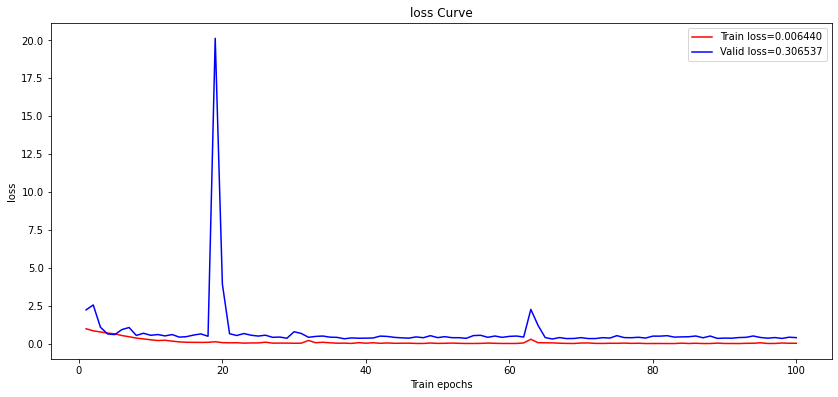

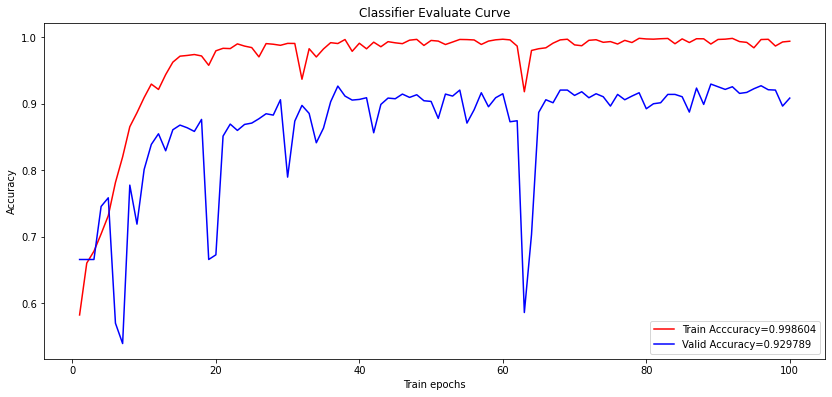

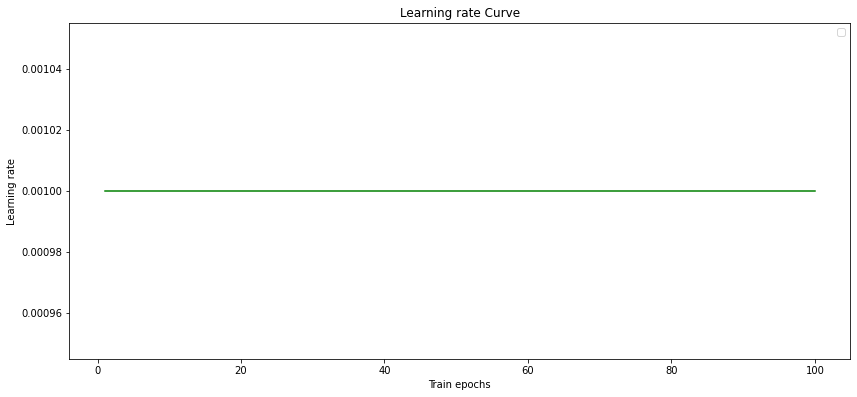

In [28]:
DisplayCurve(history=History,epoch=Epoch)

In [29]:
#保存模型
CerebriScan_V3.save('/root/Models/CerebriScan_V3.h5')
CerebriScan_V3.save('/root/Models/CerebriScan_V3')

INFO:tensorflow:Assets written to: /root/Models/CerebriScan_V3/assets


INFO:tensorflow:Assets written to: /root/Models/CerebriScan_V3/assets


模型评估

In [30]:
#计算训练集Accuracy
CerebriScan_V3.evaluate(ImageDataset_Train,return_dict=True)

2025-08-04 22:50:21.751537: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_STRING
      type: DT_INT64
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 4655
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\024TensorSliceDataset:0"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_STRING
        }
      }
      args {
        

94/94 [==============================] - 57s 593ms/step - loss: 0.0015 - accuracy: 1.0000


{'loss': 0.0014573184307664633, 'accuracy': 1.0}

In [31]:
#评估验证集Accuracy
CerebriScan_V3.evaluate(ImageDataset_Valid,return_dict=True)

2025-08-04 22:51:38.142069: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_STRING
      type: DT_INT64
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 997
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\024TensorSliceDataset:6"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_STRING
        }
      }
      args {
        t

20/20 [==============================] - 12s 573ms/step - loss: 0.3973 - accuracy: 0.9092


{'loss': 0.39733269810676575, 'accuracy': 0.9092276692390442}

In [32]:
#计算训练集Accuracy
CerebriScan_V3.evaluate(ImageDataset_Test,return_dict=True)

2025-08-04 22:51:54.073589: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_STRING
      type: DT_INT64
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 998
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\025TensorSliceDataset:12"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_STRING
        }
      }
      args {
        

20/20 [==============================] - 12s 579ms/step - loss: 0.4016 - accuracy: 0.9163


{'loss': 0.4015984833240509, 'accuracy': 0.9163326621055603}

In [33]:
#模型评估函数
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score
def ShowDNNConfusionMatrix(Model,Dataset):
    #提取数据原始标签
    True_label=[]
    Proba=[]
    index_proba=[0,1,2]
    Predict_Label=[]
    for data,labelN in Dataset:
        Predict_Proba=Model.predict(data)
        for proba,label in zip(Predict_Proba,labelN):
            True_label.append(label)
            index=np.argmax(proba)
            label=index_proba[index]
            Predict_Label.append(label)
    Label=np.array(True_label)
    PredictLabel=np.array(Predict_Label)
    TestPrecision=precision_score(Label,PredictLabel,average='micro')
    TestRecall=recall_score(Label,PredictLabel,average='micro')
    TestF1=f1_score(Label,PredictLabel,average='micro')
    TestAccuracy=accuracy_score(Label,PredictLabel)
    print('模型测试集Precision:{0},Recall:{1},F1_score:{2},Accuracy:{3}'.format(TestPrecision,TestRecall,TestF1,TestAccuracy))
    print('-------------------数据集混淆举证-------------------')
    ConfusionMatrix_result=confusion_matrix(Label,PredictLabel,labels=[0,1,2])    #计算混淆举证
    Display_ConfusionMatrix=ConfusionMatrixDisplay(ConfusionMatrix_result,display_labels=['Normal','Ischemia','Bleeding'])
    Display_ConfusionMatrix.plot(include_values=True, cmap='viridis', xticks_rotation='horizontal', values_format='d', ax=None)
    plt.title('Confusion Matrix')
    plt.show()

2025-08-04 22:55:24.508364: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Did not find a shardable source, walked to a node which is not a dataset: name: "FlatMapDataset/_9"
op: "FlatMapDataset"
input: "PrefetchDataset/_8"
attr {
  key: "Targuments"
  value {
    list {
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: -2
  }
}
attr {
  key: "f"
  value {
    func {
      name: "__inference_Dataset_flat_map_slice_batch_indices_2588013"
    }
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\023FlatMapDataset:3968"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: -1
        }
      }
    }
  }
}
attr {
  key: "output_types"
  value {
    list {
      type: DT_INT64
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_P

4/4 [==============================] - 1s 121ms/step


2025-08-04 22:55:25.861518: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Did not find a shardable source, walked to a node which is not a dataset: name: "FlatMapDataset/_9"
op: "FlatMapDataset"
input: "PrefetchDataset/_8"
attr {
  key: "Targuments"
  value {
    list {
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: -2
  }
}
attr {
  key: "f"
  value {
    func {
      name: "__inference_Dataset_flat_map_slice_batch_indices_2588638"
    }
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\023FlatMapDataset:3995"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: -1
        }
      }
    }
  }
}
attr {
  key: "output_types"
  value {
    list {
      type: DT_INT64
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_P

4/4 [==============================] - 1s 142ms/step


2025-08-04 22:55:27.268679: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Did not find a shardable source, walked to a node which is not a dataset: name: "FlatMapDataset/_9"
op: "FlatMapDataset"
input: "PrefetchDataset/_8"
attr {
  key: "Targuments"
  value {
    list {
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: -2
  }
}
attr {
  key: "f"
  value {
    func {
      name: "__inference_Dataset_flat_map_slice_batch_indices_2589263"
    }
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\023FlatMapDataset:4022"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: -1
        }
      }
    }
  }
}
attr {
  key: "output_types"
  value {
    list {
      type: DT_INT64
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_P

...

4/4 [==============================] - 1s 141ms/step


2025-08-04 22:58:09.148499: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Did not find a shardable source, walked to a node which is not a dataset: name: "FlatMapDataset/_9"
op: "FlatMapDataset"
input: "PrefetchDataset/_8"
attr {
  key: "Targuments"
  value {
    list {
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: -2
  }
}
attr {
  key: "f"
  value {
    func {
      name: "__inference_Dataset_flat_map_slice_batch_indices_2645513"
    }
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\023FlatMapDataset:6452"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: -1
        }
      }
    }
  }
}
attr {
  key: "output_types"
  value {
    list {
      type: DT_INT64
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_P

4/4 [==============================] - 1s 121ms/step


2025-08-04 22:58:10.114668: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Did not find a shardable source, walked to a node which is not a dataset: name: "FlatMapDataset/_9"
op: "FlatMapDataset"
input: "PrefetchDataset/_8"
attr {
  key: "Targuments"
  value {
    list {
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: -2
  }
}
attr {
  key: "f"
  value {
    func {
      name: "__inference_Dataset_flat_map_slice_batch_indices_2646138"
    }
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\023FlatMapDataset:6479"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: -1
        }
      }
    }
  }
}
attr {
  key: "output_types"
  value {
    list {
      type: DT_INT64
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_P

1/1 [==============================] - 0s 215ms/step
模型测试集Precision:1.0,Recall:1.0,F1_score:1.0,Accuracy:1.0
-------------------数据集混淆举证-------------------


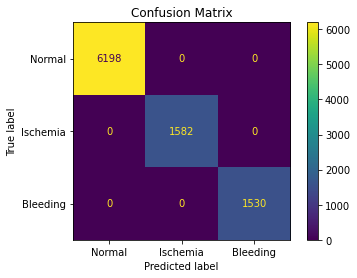

In [37]:
#训练集
ShowDNNConfusionMatrix(Model=CerebriScan_V3,Dataset=ImageDataset_Train)

2025-08-04 22:54:19.450696: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Did not find a shardable source, walked to a node which is not a dataset: name: "FlatMapDataset/_9"
op: "FlatMapDataset"
input: "PrefetchDataset/_8"
attr {
  key: "Targuments"
  value {
    list {
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: -2
  }
}
attr {
  key: "f"
  value {
    func {
      name: "__inference_Dataset_flat_map_slice_batch_indices_2575545"
    }
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\023FlatMapDataset:3427"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: -1
        }
      }
    }
  }
}
attr {
  key: "output_types"
  value {
    list {
      type: DT_INT64
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_P

4/4 [==============================] - 1s 124ms/step


2025-08-04 22:54:20.820011: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Did not find a shardable source, walked to a node which is not a dataset: name: "FlatMapDataset/_9"
op: "FlatMapDataset"
input: "PrefetchDataset/_8"
attr {
  key: "Targuments"
  value {
    list {
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: -2
  }
}
attr {
  key: "f"
  value {
    func {
      name: "__inference_Dataset_flat_map_slice_batch_indices_2576170"
    }
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\023FlatMapDataset:3454"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: -1
        }
      }
    }
  }
}
attr {
  key: "output_types"
  value {
    list {
      type: DT_INT64
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_P

4/4 [==============================] - 1s 143ms/step


2025-08-04 22:54:22.529249: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Did not find a shardable source, walked to a node which is not a dataset: name: "FlatMapDataset/_9"
op: "FlatMapDataset"
input: "PrefetchDataset/_8"
attr {
  key: "Targuments"
  value {
    list {
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: -2
  }
}
attr {
  key: "f"
  value {
    func {
      name: "__inference_Dataset_flat_map_slice_batch_indices_2576795"
    }
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\023FlatMapDataset:3481"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: -1
        }
      }
    }
  }
}
attr {
  key: "output_types"
  value {
    list {
      type: DT_INT64
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_P

...

4/4 [==============================] - 1s 134ms/step


2025-08-04 22:54:45.047894: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Did not find a shardable source, walked to a node which is not a dataset: name: "FlatMapDataset/_9"
op: "FlatMapDataset"
input: "PrefetchDataset/_8"
attr {
  key: "Targuments"
  value {
    list {
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: -2
  }
}
attr {
  key: "f"
  value {
    func {
      name: "__inference_Dataset_flat_map_slice_batch_indices_2586795"
    }
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\023FlatMapDataset:3913"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: -1
        }
      }
    }
  }
}
attr {
  key: "output_types"
  value {
    list {
      type: DT_INT64
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_P

4/4 [==============================] - 1s 123ms/step


2025-08-04 22:54:46.248101: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Did not find a shardable source, walked to a node which is not a dataset: name: "FlatMapDataset/_9"
op: "FlatMapDataset"
input: "PrefetchDataset/_8"
attr {
  key: "Targuments"
  value {
    list {
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: -2
  }
}
attr {
  key: "f"
  value {
    func {
      name: "__inference_Dataset_flat_map_slice_batch_indices_2587420"
    }
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\023FlatMapDataset:3940"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: -1
        }
      }
    }
  }
}
attr {
  key: "output_types"
  value {
    list {
      type: DT_INT64
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_P

3/3 [==============================] - 1s 293ms/step
模型测试集Precision:0.9092276830491475,Recall:0.9092276830491475,F1_score:0.9092276830491475,Accuracy:0.9092276830491475
-------------------数据集混淆举证-------------------


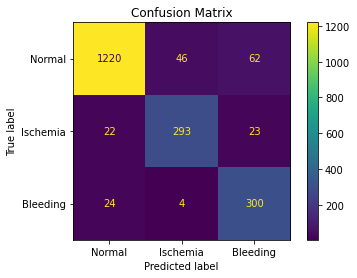

In [36]:
#验证集
ShowDNNConfusionMatrix(Model=CerebriScan_V3,Dataset=ImageDataset_Valid)

2025-08-04 22:52:46.901594: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Did not find a shardable source, walked to a node which is not a dataset: name: "FlatMapDataset/_9"
op: "FlatMapDataset"
input: "PrefetchDataset/_8"
attr {
  key: "Targuments"
  value {
    list {
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: -2
  }
}
attr {
  key: "f"
  value {
    func {
      name: "__inference_Dataset_flat_map_slice_batch_indices_2560041"
    }
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\023FlatMapDataset:2888"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: -1
        }
      }
    }
  }
}
attr {
  key: "output_types"
  value {
    list {
      type: DT_INT64
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_P

4/4 [==============================] - 6s 194ms/step


2025-08-04 22:52:53.505523: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Did not find a shardable source, walked to a node which is not a dataset: name: "FlatMapDataset/_9"
op: "FlatMapDataset"
input: "PrefetchDataset/_8"
attr {
  key: "Targuments"
  value {
    list {
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: -2
  }
}
attr {
  key: "f"
  value {
    func {
      name: "__inference_Dataset_flat_map_slice_batch_indices_2563697"
    }
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\023FlatMapDataset:2915"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: -1
        }
      }
    }
  }
}
attr {
  key: "output_types"
  value {
    list {
      type: DT_INT64
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_P

4/4 [==============================] - 1s 122ms/step


2025-08-04 22:52:54.897738: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Did not find a shardable source, walked to a node which is not a dataset: name: "FlatMapDataset/_9"
op: "FlatMapDataset"
input: "PrefetchDataset/_8"
attr {
  key: "Targuments"
  value {
    list {
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: -2
  }
}
attr {
  key: "f"
  value {
    func {
      name: "__inference_Dataset_flat_map_slice_batch_indices_2564322"
    }
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\023FlatMapDataset:2942"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: -1
        }
      }
    }
  }
}
attr {
  key: "output_types"
  value {
    list {
      type: DT_INT64
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_P

...

4/4 [==============================] - 1s 141ms/step


2025-08-04 22:53:17.779666: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Did not find a shardable source, walked to a node which is not a dataset: name: "FlatMapDataset/_9"
op: "FlatMapDataset"
input: "PrefetchDataset/_8"
attr {
  key: "Targuments"
  value {
    list {
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: -2
  }
}
attr {
  key: "f"
  value {
    func {
      name: "__inference_Dataset_flat_map_slice_batch_indices_2574322"
    }
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\023FlatMapDataset:3374"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: -1
        }
      }
    }
  }
}
attr {
  key: "output_types"
  value {
    list {
      type: DT_INT64
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_P

4/4 [==============================] - 1s 143ms/step


2025-08-04 22:53:19.144366: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Did not find a shardable source, walked to a node which is not a dataset: name: "FlatMapDataset/_9"
op: "FlatMapDataset"
input: "PrefetchDataset/_8"
attr {
  key: "Targuments"
  value {
    list {
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: -2
  }
}
attr {
  key: "f"
  value {
    func {
      name: "__inference_Dataset_flat_map_slice_batch_indices_2574942"
    }
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\023FlatMapDataset:3401"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
        dim {
          size: 32
        }
      }
    }
  }
}
attr {
  key: "output_types"
  value {
    list {
      type: DT_INT64
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_P

3/3 [==============================] - 1s 194ms/step
模型测试集Precision:0.9148296593186372,Recall:0.9148296593186372,F1_score:0.9148296593186372,Accuracy:0.9148296593186372
-------------------数据集混淆举证-------------------


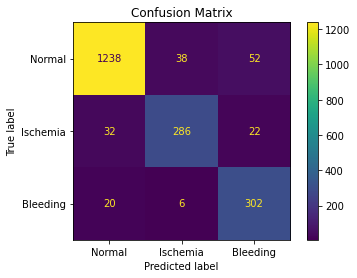

In [35]:
#测试集
ShowDNNConfusionMatrix(Model=CerebriScan_V3,Dataset=ImageDataset_Test)